# 1.Setup Environment Variables

In [21]:

import dotenv
import os

# Load environment variables from the .env file
dotenv.load_dotenv()

# Groq is the LLM provider, Tavily and Serper are for web search. 
# We set the API keys as environment variables for secure access.

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY") 
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")

print("API keys have been set securely.")

API keys have been set securely.


In [22]:
from langchain.chat_models import init_chat_model

# Use the Groq LLM for generating responses
chat_model = init_chat_model(
    model="groq:llama-3.3-70b-versatile", # Specify the Groq LLM model to use
    temperature=0.3, # Temperature (range 0-1) controls the creativity of the responses. Lower values = more deterministic, higher values = increase randomness.
    top_p=0.9, # Top-p (nucleus sampling) controls the diversity of the responses. The model considers only the most probable tokens whose cumulative probability exceeds top_p.
    max_tokens=2048, # Maximum number of tokens in the generated response. Adjust based on your needs and model limits.
)

print("Chat model initialized with Groq LLM.", chat_model)

Chat model initialized with Groq LLM. output_version=None profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x000002351CDC4DA0> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002351CDC4F50> model_name='llama-3.3-70b-versatile' temperature=0.3 model_kwargs={'top_p': 0.9} groq_api_key=SecretStr('**********') groq_api_base=None groq_proxy=None max_tokens=2048


c:\ai_projects\ai_travel_itinerary_planner\travitnary\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! top_p is not default parameter.
                    top_p was transferred to model_kwargs.
                    Please confirm that top_p is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


# 2.Creating Search Functionality

In [23]:
from langchain_tavily import TavilySearch

# Initialize the Tavily search tool with the API key
tavily_search = TavilySearch(
    max_results=5, # Maximum number of search results to return
    topic = "general", # Topic for the search
    search_depth = "advanced", # Search depth can be "basic" or "advanced" depending on how thorough you want the search to be
    include_images = False, # Whether to include images in the search results
    include_answer = True, # Whether to include direct answers in the search results
    time_range = "month", # Time range for search results (e.g., "day", "week", "month", "year")
    include_domains = ["tripadvisor.com", "booking.com","airbnb.com","trip.com","agoda.com"], # List of trusted domains to include in the search results
)

print("Tavily search tool initialized.", tavily_search)

Tavily search tool initialized. include_domains=['tripadvisor.com', 'booking.com', 'airbnb.com', 'trip.com', 'agoda.com'] search_depth='advanced' include_images=False time_range='month' max_results=5 topic='general' include_answer=True api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)


In [24]:
from langchain_community.utilities import GoogleSerperAPIWrapper

google_search = GoogleSerperAPIWrapper()

print("Google Serper search tool initialized.", google_search)

Google Serper search tool initialized. k=10 gl='us' hl='en' type='search' result_key_for_type={'news': 'news', 'places': 'places', 'images': 'images', 'search': 'organic'} tbs=None serper_api_key='72cea07da5fe5d2e93993587acc90bb8b4e27e8a' aiosession=None


# 3.Test Search functionalities

In [25]:
tavily_query = tavily_search.invoke({"query": "Best hotels in Paris for a family of 4 in June"})
print("Tavily search results:", tavily_query.get("results")[0].get("content"))

Tavily search results: Stylish, spacious rooms with modern amenities; executive and family suites ideal for couples or families. Quiet location with easy


In [26]:
google_query_results = google_search.run("Best hotels in Paris for a family of 4 in June")

print("Google Serper search results:", google_query_results)

Google Serper search results: Looking or a place to stay in Paris with a family of 5 or 6? This post has fantastic options for family accomodations around the city. Find the right hotel for you · 1. Hôtel Astra Opéra - Astotel · 2. Hotel Astoria - Astotel · 3. Hotel Eiffel Seine · 4. Victoria Palace Hotel ... I have stayed at Hotel Excelsior Latin twice. They have family rooms and suites that sleep up to 5 people. Near the Sorbonne, Pantheon, and the Luxembourg ... Missing: June | Show results with:June. The Peninsula Paris · Hôtel Des Grands Voyageurs · Hôtel Plaza Athénée, Dorchester Collection · Maison Bréguet · Cheval Blanc Paris · Le Bristol ... We are doing a family room (two connecting rooms with two bathrooms) at the Hotel Londres Eiffel.|Hotel Relais Bosquet near Rue Cler and the ... Why it's great for a family-friendly adventure: Hotel Des Arts Paris Montmartre is an inviting haven for families, featuring a top review rating of 9.8. Missing: June | Show results with:June. Try

* Lets define functions for above search functionalities so we can reuse them

In [27]:
from langchain_core.tools import tool

@tool
def tavily_search_tool(query: str) -> str:
    """Searches for information using the Tavily search tool."""
    return tavily_search.invoke({"query": query})

@tool
def google_serper_search_tool(query: str) -> str:
    """Searches for information using the Google Serper search tool."""
    return google_search.run(query)
    

In [28]:
tavily_search_tool.invoke("Plan a trip to India for 10 days in June for a family of 4. Include top tourist attractions, hotels, and local cuisine recommendations.")

{'query': 'Plan a trip to India for 10 days in June for a family of 4. Include top tourist attractions, hotels, and local cuisine recommendations.',
 'response_time': 2.63,
 'follow_up_questions': None,
 'answer': 'For a 10-day trip to India in June, visit Delhi, Agra (Taj Mahal), Jaipur, and Udaipur. Stay at Hotel Ivory Palace in Delhi. Try local dishes like butter chicken and samosas.',
 'images': [],
 'results': [{'url': 'https://sg.trip.com/travel-guide/destination/india-100080/',
   'title': 'India Travel Guide 2026: Top places, Itinerary & Deals | Trip.com | April 2026',
   'content': "Hotels\n\n### Popular Vacation Homes in India\n\nPopular Hot Springs Attractions in India\n\nAttraction\n\n### Popular Hot Springs Attractions in India\n\n## Popular Destinations\n\nNew Delhi\n\n### New Delhi\n\nMumbai\n\n### Mumbai\n\nBengaluru\n\n### Bengaluru\n\nJaipur\n\n### Jaipur\n\nPune\n\n### Pune\n\n## Things to do in India\n\n### What to do\n\nLooking for things to do in India? We provide

In [29]:
google_serper_search_tool.invoke("Plan a trip to India for 10 days in June for a family of 4. Include top tourist attractions, hotels, and local cuisine recommendations.")

"Itinerary #1: Family Adventure in India's Golden Triangle ; Day 7, Tiger Safari in Ranthambore National Park, Ranthambore Fort, Ranthambore ; Day ... Missing: June | Show results with:June. Explore India itineraries from 7–14 days. Get inspired and customize your trip with Rough Guides' local experts for stress-free travel. Missing: cuisine | Show results with:cuisine. My India Travel Itinerary will show you some of India's highlights, such as the breathtaking Taj Mahal, the UNESCO World Heritage Forts, and the beautiful ... Missing: local | Show results with:local. Embark on a 5 Nights/6 Days Golden Triangle Tour starting and ending in New Delhi. This trip covers the three most prominent tourist ... Missing: June | Show results with:June. India 10-Day Itinerary Options · Itinerary #1: Desert at Jaipur and Lakes of Udaipur · Itinerary #2: Heaven in Kerala · Itinerary #3: Vacation in Himachal and ... We recommend starting off with a few of Delhi's favorite bazaars – browse for clothes 

# 4.Create agent

In [30]:
from langchain.agents import create_agent
# It best to keep system prompts concise and focused so we don't use up too many tokens on instructions. 

system_prompt = """
You are helpful, empathetic travel planner assistant.
Use web search tools to provide accurate, up-to-date itineraries based on search results.
Ask for clarifying details if needed. Format responses with headings, bullet points, images, costs and sources.
Cite sources. Do not make up information. If you don't know the answer, say you don't know.
"""

travel planner agent created!


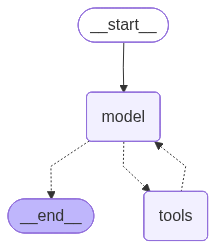

In [31]:
agent = create_agent(
    model=chat_model,
    tools=[tavily_search_tool,google_serper_search_tool],
    system_prompt=system_prompt.strip()    # instructions for the agent
)

print("travel planner agent created!")
agent

# 5.Test Agent

In [39]:
response = agent.invoke({
    "messages":[
        {"role": "user", "content": "Plan a luxurytrip to Shimmla for 3 days in January for a family of 3. Include top tourist attractions, hotels, and local cuisine recommendations."}
    ]
})

print("Agent response:\n", response)

Agent response:
 {'messages': [HumanMessage(content='Plan a luxurytrip to Shimmla for 3 days in January for a family of 3. Include top tourist attractions, hotels, and local cuisine recommendations.', additional_kwargs={}, response_metadata={}, id='a7ee8509-7bdd-42ea-9678-b06eea19bc09'), AIMessage(content="## Introduction to Shimla\nShimla, the capital city of Himachal Pradesh, is a popular tourist destination in India. It is known for its natural beauty, rich history, and luxurious amenities. A 3-day trip to Shimla in January can be a great way to experience the city's winter charm.\n\n## Top Tourist Attractions\nSome of the top tourist attractions in Shimla include:\n* The Mall Road: a popular shopping and dining destination\n* The Ridge: a scenic spot with great views of the surrounding mountains\n* Jakhoo Temple: a historic temple dedicated to Lord Hanuman\n* Kufri: a nearby hill station with great skiing and trekking opportunities\n* Christ Church: a historic church with stunning 

In [41]:
final_answer = response["messages"][-1].content
print("Final answer:\n", final_answer)

Final answer:
 ## Luxury Trip to Shimla for 3 Days in January for a Family of 3

### Top Tourist Attractions:

* Jakhu Temple
* Viceregal Lodge (now the Vice President's residence)
* Mall Road for shopping and dining

### Luxury Hotels:

* The Oberoi Cecil
* Wildflower Hall, An Oberoi Resort
* Radisson Hotel Kufri Shimla
* WelcomHeritage Elysium Resort & Spa
* Taj Theog Resort & Spa Shimla

### Local Cuisine Recommendations:

* Himachali dishes like sidu, bhaang, and chha Gosht
* Cafe Simla Times
* Goofa Ashiana Restaurant
* Hills Edge Restaurant

### Weather in January:

* Average high temperature: 57°F (14°C)
* Average low temperature: 36°F (2°C)
* Moderately chilly weather

### Itinerary:

Day 1: Arrival in Shimla and check-in to a luxury hotel. Visit the Jakhu Temple and explore the Mall Road for shopping and dining.

Day 2: Visit the Viceregal Lodge and enjoy a guided tour of the city. Try some local Himachali cuisine at one of the recommended restaurants.

Day 3: Spend the day ex